In [1]:
import re
import os
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import SimpleITK as sitk

# Functions

In [11]:
def parse_mask_filename(filename: str):
    """
    Extract region, center, and year from filenames like:
    - AB_1ABC118_mask.nii.gz
    - brain_1BA345_mask.nii.gz

    Rules:
    - Extract the part between the first and second underscore.
    - center = last letter of that segment
    - region = all letters before the center
    - year = 2023 if region is 'B' or 'P', otherwise 2025
    """
    # Get substring between first and second underscore
    match = re.search(r'^[^_]+_([^_]+)_', filename)
    if not match:
        raise ValueError(f"Filename format not recognized: {filename}")

    middle = match.group(1)

    # Extract letters only
    letters = re.findall(r'[A-Za-z]', middle)
    if not letters:
        raise ValueError(f"No letters found in middle segment of {filename}")

    center = letters[-1]
    region = ''.join(letters[:-1])

    # Year rule
    year = "2023" if region in ("B", "P") else "2025"

    center_year = center + "_" + year

    return region, center_year

def find_mask_sizes(mask_paths):
    rows = []
    for path in tqdm(mask_paths):
        volume_id = path.split("/")[-1]
        region, center_year = parse_mask_filename(volume_id)
        img = sitk.ReadImage(str(path))
        arr = sitk.GetArrayFromImage(img).astype(np.uint8)  # [z, y, x]
        
        Z, H, W = arr.shape
        
        for z in range(Z):
            slice_mask = arr[z] > 0
            if not slice_mask.any():
                continue  # skip empty slices
            
            ys, xs = np.where(slice_mask)
            y_min, y_max = ys.min(), ys.max()
            x_min, x_max = xs.min(), xs.max()
            
            bbox_height = y_max - y_min + 1
            bbox_width  = x_max - x_min + 1
            mask_area   = slice_mask.sum()
            
            rows.append({
                "volume_id": volume_id,
                "region": region,
                "center_year": center_year,
                "slice_idx": z,
                "orig_height": H,
                "orig_width": W,
                "y_min": y_min,
                "y_max": y_max,
                "x_min": x_min,
                "x_max": x_max,
                "bbox_height": bbox_height,
                "bbox_width": bbox_width,
                "mask_area": int(mask_area),
            })

    # Save metadata for later analysis
    df = pd.DataFrame(rows)

    return df

def plot_bbox_heatmap(df, regions=None, bins=50, threshold=None):
    if regions is not None:
        if isinstance(regions, str):
            regions = [regions]
        df = df[df['region'].isin(regions)]

    max_val = max(df['bbox_width'].max(), df['bbox_height'].max())

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(cmap(0))  # map NaN/zero bins to the lowest viridis color

    h = ax.hist2d(
        df['bbox_width'],
        df['bbox_height'],
        bins=bins,
        range=[[0, max_val], [0, max_val]],
        cmap=cmap,
        norm=mcolors.LogNorm(),
        rasterized=True
    )
    fig.colorbar(h[3], ax=ax, label="Count")
    ax.set_xlabel("Mask BB Width per Slice [in pixels]")
    ax.set_ylabel("Mask BB Height per Slice [in pixels]")
    ax.set_aspect('equal', adjustable='box')

    if threshold is not None:
        # Convert threshold from data coords to axes fraction
        ax_frac = threshold / max_val

        ax.axvline(x=threshold, color='red', linestyle='--', linewidth=1, ymax=ax_frac)
        ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1, xmax=ax_frac)

    fig.tight_layout()
    return fig

def cropping_loss_share(df, regions, min_size):
    """
    df       : DataFrame with at least columns ['region', 'bbox_height', 'bbox_width'] (and optionally 'max_bbox')
    regions  : list-like of region names to filter on
    min_size : threshold for max_bbox (inclusive)
    
    Returns: float in [0, 1] = share of rows (for given regions)
             whose max_bbox >= min_size.
             Returns np.nan if there are no rows for those regions.
    """
    # restrict to selected regions
    sub = df[df['region'].isin(regions)].copy()
    
    if sub.empty:
        return np.nan  # or 0.0, depending on what you prefer

    # ensure max_bbox exists (recompute if necessary)
    if 'max_bbox' not in sub.columns:
        sub['max_bbox'] = sub[['bbox_height', 'bbox_width']].max(axis=1)

    # boolean mask where max_bbox >= min_size
    share = (sub['max_bbox'] >= min_size).mean()
    return float(share)

# Data Loading

In [3]:
# find filenames per data split (to work in 1initNifti)
datadir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/1initNifti"
outdir = "/home/user/nschuler/fullbody-sCT/analysis"
os.chdir(outdir)
split = pd.read_csv("../preprocessing/preprocessing_synthrad/splits_manifest.csv")
split["folder"] = split["example_path"].str.split("/").str[-1]
split["filename"] = split["folder"] + "_mask.nii.gz"
# # for old masks
# split["path"] = split["folder"] + "/masks/" + split["filename"]
# for new masks
split["path"] = split["folder"] + "/new_masks/" + split["filename"].str.replace("mask", "mask_from_CT_treshold")
all_files = split["path"].tolist()


# Calculate mask sizes
# os.chdir(datadir)
# mask_sizes = find_mask_sizes(all_files)
# os.chdir(outdir)
# mask_sizes.to_csv("new_mask_dimensions.csv", index=False)
# # for old masks
# mask_sizes.to_csv("mask_dimensions.csv", index=False)

# Load pre-calculated mask sizes for analysis
os.chdir(outdir)
mask_sizes = pd.read_csv("new_mask_dimensions.csv")
# # for old masks
# mask_sizes = pd.read_csv("mask_dimensions.csv")

mask_sizes['max_bbox'] = mask_sizes[['bbox_height', 'bbox_width']].max(axis=1)

# Analysis Share of Masks with Cropping Losses

In [4]:
regions = ["AB", "TH", "P"]
print(regions)
for i in range(7):
    scale_factor = round(0.8 + i/5, 1)
    size_px = round(scale_factor * 256)
    loss = cropping_loss_share(mask_sizes, regions=regions, min_size=size_px)
    print(f"Factor {scale_factor}: Loss of mask area in {round(loss*100, 2)}% of slices")

['AB', 'TH', 'P']
Factor 0.8: Loss of mask area in 98.58% of slices
Factor 1.0: Loss of mask area in 97.82% of slices
Factor 1.2: Loss of mask area in 90.73% of slices
Factor 1.4: Loss of mask area in 60.47% of slices
Factor 1.6: Loss of mask area in 18.57% of slices
Factor 1.8: Loss of mask area in 3.84% of slices
Factor 2.0: Loss of mask area in 0.66% of slices


In [5]:
regions = ["B", "HN"]
print(regions)
for i in range(7):
    scale_factor = round(0.8 + i/5, 1)
    size_px = round(scale_factor * 256)
    loss = cropping_loss_share(mask_sizes, regions=regions, min_size=size_px)
    print(f"Factor {scale_factor}: Loss of mask area in {round(loss*100, 2)}% of slices")

['B', 'HN']
Factor 0.8: Loss of mask area in 16.25% of slices
Factor 1.0: Loss of mask area in 4.77% of slices
Factor 1.2: Loss of mask area in 4.35% of slices
Factor 1.4: Loss of mask area in 4.06% of slices
Factor 1.6: Loss of mask area in 3.31% of slices
Factor 1.8: Loss of mask area in 1.38% of slices
Factor 2.0: Loss of mask area in 0.3% of slices


# Plotting of Bounding Box sizes

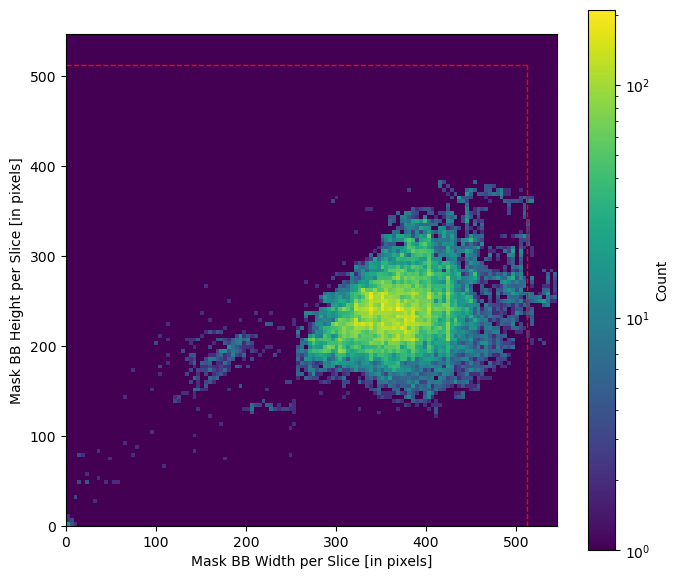

In [12]:
os.chdir("/home/user/nschuler/fullbody-sCT")
fig = plot_bbox_heatmap(mask_sizes, regions=["AB", "TH", "P"], bins=128, threshold=512)
fig.savefig("image_size_pelvis_AB_TH.pdf", bbox_inches="tight")

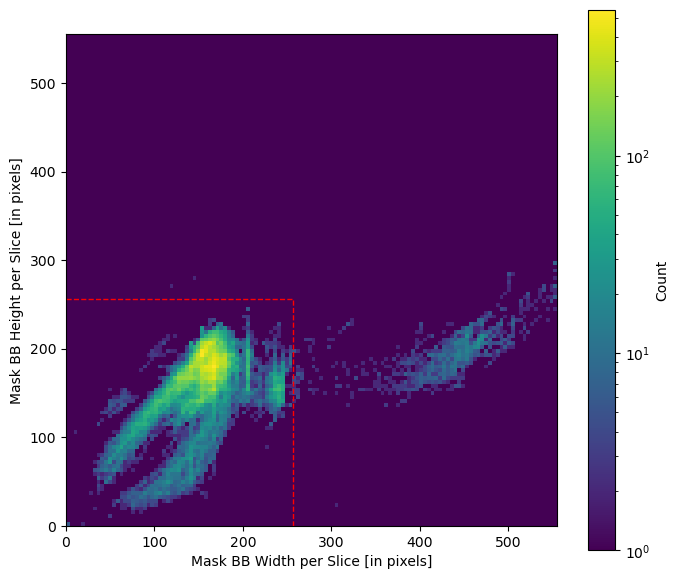

In [13]:
fig = plot_bbox_heatmap(mask_sizes, regions=["B", "HN"], bins=128, threshold=256)
fig.savefig("image_size_brain_HN.pdf", bbox_inches="tight")

In [8]:
df_by_volume = (
    mask_sizes
    .groupby(['volume_id', 'region', 'center_year', 'orig_height', 'orig_width'])
    [['bbox_height', 'bbox_width', 'mask_area']]
    .agg(['median', 'max'])
)

df_by_volume.columns = ['_'.join(col) for col in df_by_volume.columns]
df_by_volume = df_by_volume.reset_index()
df_by_volume.sample(10)

,volume_id,region,center_year,orig_height,orig_width,bbox_height_median,bbox_height_max,bbox_width_median,bbox_width_max,mask_area_median,mask_area_max
461,TH_1THA261_mask_from_CT_treshold.nii.gz,TH,A_2025,479,467,288.0,309,409.0,420,92486.0,95913
153,AB_1ABB169_mask_from_CT_treshold.nii.gz,AB,B_2025,391,399,234.0,246,317.0,354,63261.0,71980
343,HN_1HND027_mask_from_CT_treshold.nii.gz,HN,D_2025,270,279,178.0,189,168.0,243,24977.0,28954
460,TH_1THA260_mask_from_CT_treshold.nii.gz,TH,A_2025,458,475,246.0,285,425.0,427,82374.5,100355
387,HN_1HND094_mask_from_CT_treshold.nii.gz,HN,D_2025,273,279,171.0,188,169.0,243,24235.0,29154
532,TH_1THB095_mask_from_CT_treshold.nii.gz,TH,B_2025,440,443,279.0,296,364.0,402,85640.0,87981
258,HN_1HNA133_mask_from_CT_treshold.nii.gz,HN,A_2025,317,244,161.0,175,163.0,206,21843.0,32660
262,HN_1HNA139_mask_from_CT_treshold.nii.gz,HN,A_2025,321,246,183.5,193,192.0,208,27189.5,34000
636,brain_1BA368_mask_from_CT_treshold.nii.gz,B,A_2023,240,195,175.0,210,151.0,164,19855.0,25525
683,brain_1BB111_mask_from_CT_treshold.nii.gz,B,B_2023,232,211,169.0,198,152.0,173,21633.0,24377
